# 02 · Baselines

**Question:** how good are the *simplest possible* forecasts?

A machine learning model is only useful if it beats these. Every solar forecasting paper
reports a baseline, usually **persistence**, and measures other models against it.

**The task (same for every model in this project):** predict the energy (kWh) of the
**next hour**, using only data up to now.

**The split:**

| Split | Year | Used for |
|---|---|---|
| Train | 2017 | learning patterns |
| Validation | 2018 | choosing settings, comparing ideas |
| Test | 2019 | final score, used once at the end |

**Night hours are not scored.** Predicting 0 at night is trivial and would make every model look better.

In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))              # lets us import our own code from src/

from src.data import load_hourly, split
from src.metrics import evaluate

FIGURES = ROOT / "results" / "figures"
RESULTS = ROOT / "results"

y = load_hourly()                          # hourly energy, local time
print(y.index.min(), "->", y.index.max(), "|", len(y), "hours")

2017-01-01 00:00:00-08:00 -> 2019-10-27 09:00:00-07:00 | 24705 hours


## The four baselines

Each one predicts the next hour, **t+1**, using only what we know at hour **t**.

| Baseline | Rule | Idea |
|---|---|---|
| **Persistence** | next hour = this hour | "Nothing changes." |
| **Yesterday** | next hour = the same hour yesterday | "Today is like yesterday." |
| **Climatology** | next hour = the average for that month and hour (from 2017) | "A typical day." |
| **Smart persistence** | this hour's "weather ratio" × the typical next hour | "Keep today's cloudiness, follow the sun's daily curve." |

**Why smart persistence?** Plain persistence fails every morning and evening: at 7 AM it predicts
the 6 AM value, but the sun is rising. Smart persistence fixes that. It asks *"how sunny is it now
compared to a typical day?"* (say 70%) and applies that to the next hour's typical value.
Research normally does this with a physics "clear-sky model". We use the 2017 average as a simple
stand-in, and the physics version comes in Level 2.

In [16]:
# Climatology: average energy for each (month, hour), learned from the TRAINING year only
train = split(y, "train")
clim_table = train.groupby([train.index.month, train.index.hour]).mean()
clim = pd.Series(clim_table.reindex(list(zip(y.index.month, y.index.hour))).to_numpy(), index=y.index)

forecasts = {}
forecasts["Persistence"] = y.shift(1)                     # value one hour earlier
forecasts["Yesterday"] = y.shift(24)                      # value 24 hours earlier
forecasts["Climatology"] = clim

ratio = (y / clim).where(clim >= 0.5)                     # "how sunny vs typical", only when the sun is up
ratio = ratio.clip(0, 1.5)                                # guard against extreme ratios at dawn/dusk
smart = ratio.shift(1) * clim
forecasts["Smart persistence"] = smart.fillna(clim)       # no ratio yet (e.g. first hour of sun) -> typical value

pd.DataFrame({"actual": y, **forecasts}).loc["2019-06-10 05:00":"2019-06-10 11:00"].round(2)

,actual,Persistence,Yesterday,Climatology,Smart persistence
time,,,,,
2019-06-10 05:00:00-07:00,0.00,0.00,0.00,0.00,0.00
2019-06-10 06:00:00-07:00,0.53,0.00,0.45,0.32,0.32
2019-06-10 07:00:00-07:00,2.76,0.53,1.98,2.27,2.27
2019-06-10 08:00:00-07:00,5.44,2.76,7.41,7.41,9.02
2019-06-10 09:00:00-07:00,12.56,5.44,13.24,13.10,9.61
2019-06-10 10:00:00-07:00,15.84,12.56,17.70,18.07,17.32
2019-06-10 11:00:00-07:00,19.54,15.84,20.52,20.76,18.21


The table above shows one June morning. Notice how **Persistence** lags one hour behind the
rising sun, while **Smart persistence** follows it.

## Which hours count as "day"?

An hour is scored if its typical (climatology) energy is at least **0.5 kWh**.
This removes night, and the first and last minutes of light, where every forecast is near zero.

In [17]:
daytime = clim >= 0.5
print(f"Daytime hours: {daytime.mean():.0%} of all hours")

Daytime hours: 48% of all hours


## Scores

All forecasts are scored on **exactly the same hours**. If any forecast (or the truth) is missing
for an hour, that hour is skipped for everyone. Otherwise the comparison wouldn't be fair.

In [18]:
results = {}
for name in ["val", "test"]:
    table = evaluate(split(y, name), {k: split(v, name) for k, v in forecasts.items()}, split(daytime, name))
    results[name] = table
    print(f"{name.upper()}: scored on {table.attrs['n_hours']} daytime hours")
    display(table)

VAL: scored on 3599 daytime hours


,MAE (kWh),RMSE (kWh),nRMSE (%),Skill vs persistence
Persistence,3.528,4.277,35.101,0.000
Yesterday,2.470,4.430,36.354,-0.036
Climatology,2.660,4.089,33.552,0.044
Smart persistence,1.308,2.216,18.187,0.482


TEST: scored on 3527 daytime hours


,MAE (kWh),RMSE (kWh),nRMSE (%),Skill vs persistence
Persistence,3.403,4.112,34.035,0.000
Yesterday,2.284,4.251,35.192,-0.034
Climatology,2.459,3.889,32.193,0.054
Smart persistence,1.221,2.095,17.338,0.491


**How to read this:**

- **MAE / RMSE** are in kWh per hour. Smaller is better. For scale, a sunny midday hour is about 20–28 kWh.
- **nRMSE** is RMSE as a % of the average daytime energy, so it can be compared across datasets.
- **Skill vs persistence:** 0 means "no better than persistence". Positive is better, negative is worse.
  Every future model will report this number.

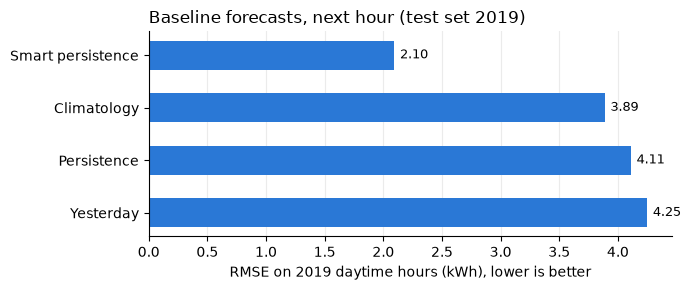

In [19]:
table = results["test"]
order = table.sort_values("RMSE (kWh)").index

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(order, table.loc[order, "RMSE (kWh)"], color="#2a78d6", height=0.55)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("RMSE on 2019 daytime hours (kWh), lower is better")
ax.set_title("Baseline forecasts, next hour (test set 2019)", loc="left")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES / "02_baseline_rmse.png", dpi=130)
plt.show()

## Look at one week

Numbers hide *how* a forecast fails. This chart shows a mixed week in March 2019, with sunny and
cloudy days.

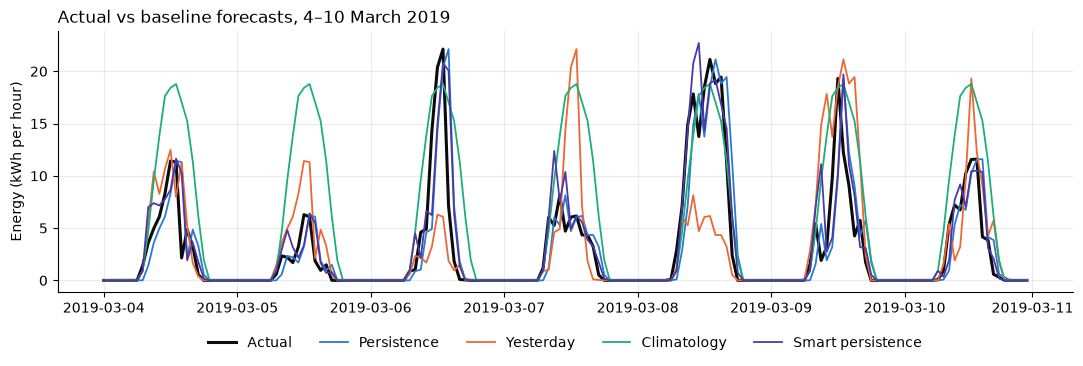

In [20]:
week = slice("2019-03-04", "2019-03-10")
colors = {"Persistence": "#2a78d6", "Yesterday": "#eb6834", "Climatology": "#1baf7a", "Smart persistence": "#4a3aa7"}

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(y.loc[week].index, y.loc[week], color="#0b0b0b", linewidth=2.2, label="Actual")
for name, c in colors.items():
    ax.plot(forecasts[name].loc[week].index, forecasts[name].loc[week], color=c, linewidth=1.3, label=name)
ax.set_ylabel("Energy (kWh per hour)")
ax.set_title("Actual vs baseline forecasts, 4–10 March 2019", loc="left")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "02_baselines_week.png", dpi=130)
plt.show()

In [21]:
# Save the scores. Every later notebook adds its models to this same table.
out = pd.concat(results, names=["split", "model"])
out.to_csv(RESULTS / "metrics_baselines.csv")
out

MAE (kWh)  RMSE (kWh)  nRMSE (%)  \
split model                                                 
val   Persistence            3.528       4.277     35.101   
      Yesterday              2.470       4.430     36.354   
      Climatology            2.660       4.089     33.552   
      Smart persistence      1.308       2.216     18.187   
test  Persistence            3.403       4.112     34.035   
      Yesterday              2.284       4.251     35.192   
      Climatology            2.459       3.889     32.193   
      Smart persistence      1.221       2.095     17.338   

                         Skill vs persistence  
split model                                    
val   Persistence                       0.000  
      Yesterday                        -0.036  
      Climatology                       0.044  
      Smart persistence                 0.482  
test  Persistence                       0.000  
      Yesterday                        -0.034  
      Climatology                       0.054  
      Smart persistence                 0.491

## What we learned

- **Smart persistence is by far the best baseline.** On 2019 it cuts the error roughly in half
  (RMSE 2.10 vs 4.11 kWh, skill 0.49). The 2018 validation year gives almost the same numbers,
  so the result is stable, not luck.
- **Plain persistence fails at sunrise and sunset**, because it lags one hour behind the sun.
  You can see this in the June-morning table and the week chart.
- **"Yesterday" has a low MAE but a high RMSE.** It is usually close, but when the weather changes
  from one day to the next it is badly wrong. RMSE punishes those big misses.
- **Climatology never reacts to clouds.** It draws the same smooth curve every day.
- **The bar to beat:** every ML model from now on must beat the **best** baseline here,
  not just plain persistence. Otherwise it isn't adding value.

**Next notebook:** `03_features_and_models.ipynb`, where we add weather and time features and train real ML models.